# Check responsivity to Emotional faces across all (pre)screened contacts for participant
Specifically designed for EmotionTask data <br>
____
**Prerequisites:** <br>
Files
- *montage.csv
- *iEEG.csv
- *events.csv <br>

Code
- numpy
- pandas
- matplotlib
- scipy
- my GRID_lab_python repo (https://github.com/jtmiles/GRID_lab_python)

_**Note on the montage.csv file:**_ <br>
Contacts should have been pre-screened for inclusion prior to running <br>
Functionally, the prescreening adds a `keep` column to the montage file <br>
The keep column is used to determine which contacts from the montage to analyze <br>



### Imports

In [1]:
# imports
import numpy as np
import pandas as pd
import os
import re
from scipy.signal import find_peaks
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter
from scipy.stats import ttest_1samp as tt1
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from iEEG_utils.loading import read_data
from iEEG_utils.processing import filtering
from iEEG_utils.spike_checks import spike_utils
from iEEG_utils import utils

# instantiate a random number generator
rng = np.random.default_rng()

### Load data/metadata

In [2]:
# use file selection dialog to choose folder with data
fstr = read_data.select_directory()
print(fstr)

C:\Users\jmile3\OneDrive - SCH\emotional_faces_data\915b69\EmotionTask


In [3]:
# load each data file

montage = read_data.load_info(fstr,ftype="montage")
montage.name = montage.name.replace(" ","",regex=True)
origfs,data = read_data.load_iEEG(fstr,load_meta=True)
events = read_data.load_info(fstr,ftype="events")
data.columns = data.columns.str.replace(r"\s+", "", regex=True)

try:
    origtime = pd.to_datetime(data.time,format='%H:%M:%S.%f')
except AttributeError:
    origtime = pd.to_datetime(data.index,format='%H:%M:%S.%f')
    
origts = np.array(origtime-origtime[0])/ np.timedelta64(1, 's')

if origfs == None:
    origfs = 1/np.diff(origts).astype("float64").mean()
    print("original sampling frequency not declared, calculated as: "+str(origfs)+" Hz")

montage = montage.loc[(montage.keep)&(montage.region!="DC_sync"),:]
display(montage)

# Align traces to image onsets
img_ts = origts[events.img_on_ix]
pairs_list = np.array(utils.find_valid_pairs(montage["name"].to_list(),montage["region"].to_list()))

# check that index is "time"
if data.index.name==None:
    data.index = data.time
    data.drop("time",axis=1,inplace=True)
    
assert data.index.name=="time","check data index values"

,ID,age,region,ch,name,keep
1,915b69,8.58,r_inferiortemporal,86,RG3,True
2,915b69,8.58,r_inferiortemporal,87,RG4,True
6,915b69,8.58,r_entorhinal,94,RB3,True
7,915b69,8.58,r_entorhinal,95,RB4,True
8,915b69,8.58,r_fusiform,96,RB5,True
9,915b69,8.58,r_fusiform,97,RB6,True
10,915b69,8.58,r_superiorparietal,51,RU8,True
11,915b69,8.58,r_superiorparietal,52,RU9,True
13,915b69,8.58,l_caudalmiddlefrontal,32,LT11,True
14,915b69,8.58,l_caudalmiddlefrontal,33,LT12,True


In [4]:
# signal processing

# parameters for signal processing
resrate = 1024
lpfreq = 300
# time prior to (pre) and after (post) image onset
pre = -1
post = 2
# parameters for noise estimation
win_dur = 0.125 # seconds
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds

# filter outside of loop, then do rereferencing inside loop for filt_data
# remove baseline drift with 1 second rolling average
hpfdata = data-data.rolling(window=int(origfs),min_periods=int(origfs/2),center=True).mean()
ts, filt_data, _ = filtering.filt_resample(hpfdata, origfs, resrate,
                                           lpfreq=lpfreq,norm="zscore")
# get image onsets for filtered/resampled data
t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()
# peri-stimulus time vector
plot_ts = np.linspace(pre,post,t_ixs.shape[1])
# define window of interest (image onset through following second)
ixA = np.argmin(np.abs(plot_ts-0.0))
ixB = np.argmin(np.abs(plot_ts-1))


In [5]:
# notebook specific functions

def mat_corr(X, Y, labels):
    '''
    Linear algebraic formulation of pearson correlation for matrices that may not broadcast nicely

    Array shapes must conform to following constraints:
    - X = (n x t)
    - Y = (t x c)

    For this notebook:
    > X contains the individual trials (n) by timepoints (t)
    > Y contains the average ERP (t) for each category (c)
    
    X and Y are centered and divided by their vector norm before taking their dot product
    
    '''
    # array of all trials (bad ones masked out)
    trials = signal[t_ixs[t_mask,ixA:ixB]]
    # calculate the ERPs for each category
    ERPs = np.array([trials[labels==ix,:].mean(axis=0) for ix in range(len(cats))]).T
    
    # center each matrix
    X_cent = X - X.mean(axis=1, keepdims=True)
    Y_cent = Y - Y.mean(axis=0, keepdims=True)
    
    # normalize by each trial/ERP's vector norm
    X_norm = X_cent / np.linalg.norm(X_cent, axis=1, keepdims=True)
    Y_norm = Y_cent / np.linalg.norm(Y_cent, axis=0, keepdims=True)
    return X_norm @ Y_norm

def corr_correct(corr_mat, X, Y, labels):
    '''
    leave one out (loo) correlation correction
    i.e., for each trial, subtract it's contribution to the ERP for it's category and recompute correlation

    looks funny because no (n-1) divisor correction, but will get same result anyway (pearson correlation invariant to scaling)

    corr_mat is a matrix (probably of single trial correlations to each category's ERP, likely returned by mat_corr fxn)
    X is a matrix (probably of trial data)
    Y is a matrix with (probably of ERPs, with one ERP per column)
    labels are the category label that each trial belongs to
    
    returns matrix of corrected correlations
    
    '''
    # n instances per category
    counts = np.bincount(labels)
    X_cent = X - X.mean(axis=1, keepdims=True)
    X_norm = X_cent / np.linalg.norm(X_cent, axis=1, keepdims=True)
    loo_corrs = corr_mat.copy() # copy b/c not all values are replaced!
    for i, k in enumerate(labels):
        # apply leave-one-out correction for trial and matching ERP category
        # this adjusts the influence of trial_i on ERP_k
        y_loo = counts[k] * Y[:, k] - X[i]
        y_loo /= np.linalg.norm(y_loo)
        # put correct trial back into it's proper column (based on category label)
        loo_corrs[i, k] = X_norm[i] @ y_loo
    return loo_corrs


def test_corrs(corr_mat, labels):
    '''
    run all the pairwise T-tests to ask if the correlations are above zero

    corr_mat is a matrix of all individual correlations for each trial x ERP
    its size is (n trials x m categories)
    columns in corr_mat are the result of correlating each individual trial by that category's ERP

    labels is an iterable of category label integer indices (e.g., fear->0, happy->1, etc.)
    (tells which trials to grab per category from corr_mat)

    *IMPORTANT*
    > To keep things simple, the label index categories should correspond exactly to corr_mat columns
      So if fear is index 0, the 0th column should be all trials correlated with the fear ERP
    
    > correlations should be leave-one-out corrected before running

    Returns a df with columns = ["comparison", "kind", "corr", "T"]
      comparison - string noting which trials were compared which ERP (e.g., "anger_anger" or "anger_neutral")
      kind - "within" or "between"
      corr - average correlation for category comparison
      T - T value of correlation distribution's difference from 0

    '''
    corrs = []
    Ts = []
    comps = []
    types = []
    # loop through ERPs categories (columns of corr_mat)
    for ii in range(corr_mat.shape[1]):
        # loop through trial categories
        #######
        # NOTE: this could be changed to the category index instead of matrix shape
        ####### however, it would be confusing if category labels didn't match column numbers
        #######
        for jj in range(corr_mat.shape[1]):
            # trials of particular label index, for current column
            corr_comp = corr_mat[labels==jj,ii]
            # add to respective lists (soon to be df columns)
            corrs.append(corr_comp.mean())
            Ts.append(tt1(corr_comp,0).statistic)
            comps.append(f"{cats[jj]}_{cats[ii]}")
            if cats[jj] == cats[ii]:
                types.append("within")
            else:
                types.append("between")
    cols = ["comparison","kind","r","T"]           
    df = pd.DataFrame({"comparison":comps,"kind":types,"R_stat":corrs,"T_stat":Ts})
    return df



In [6]:
# loop through channels to bipolar rereference and calculate correlation similarities

# ERPs or high-frequency broadband activity? (set True for HFB)
HFB_calc = True

reg_dfs = []
for pair in pairs_list:
    reg = montage.region[montage.name==pair[0]].item()
    print(reg)
    pair_ix = np.where(np.isin(data.columns, pair))[0][::-1]
    # bipolar rereference valid pairs
    signal = np.squeeze(np.diff(filt_data[:,pair_ix],axis=1))
    # see how many trials have amplitude excursions within the ERP window
    norm_env = spike_utils.envelope_noise_screen(signal, resrate, window_s=win_dur)
    # filter the trials with too many amplitude excursions in the pre/post window
    t_mask = np.sum(np.int64((norm_env>MAD_thresh)[t_ixs]),axis=1)<(min_dur*resrate)
    # update t_mask to get rid of house trials
    t_mask = t_mask & (events.img_category!="house")
    # high frequency broadband
    if HFB_calc:
        HFB = gaussian_filter(np.abs(hilbert(filtering.bfilt(signal, resrate, 4, [70,150], "bandpass"))),4)
        # HFB[norm_env>MAD_thresh] = np.nan
        signal = filtering.zscore(HFB)
    # get category labels and index them
    cats, label_ixs = np.unique(events.img_category[t_mask], return_inverse=True)
    # n instances per category
    counts = np.bincount(label_ixs)
    # array of all trials (bad ones masked out)
    trials = signal[t_ixs[t_mask,ixA:ixB]]
    # calculate the ERPs for each category
    ERPs = np.array([trials[label_ixs==ix,:].mean(axis=0) for ix in range(len(cats))]).T
    # get the correlations
    corr_mat = mat_corr(trials, ERPs, label_ixs)
    # correct for within category comparisons
    corrected = corr_correct(corr_mat, trials, ERPs, label_ixs)
    # make calculations
    df = test_corrs(corrected, label_ixs)
    # add identifiers
    df["region"] = reg
    df["ID"] = montage.ID.unique().item()
    df["age"] = montage.age.unique().item()
    # reorganize the df and add to list
    reg_dfs.append(df[["ID","age","region","comparison","kind","R_stat","T_stat"]])


l_middletemporal
l_inferiortemporal
l_fusiform
l_parahippocampal
l_temporalpole
l_caudalmiddlefrontal
r_superiorparietal
r_fusiform
r_entorhinal
r_inferiortemporal


In [7]:
savestr = fstr+fr"\EmotionTask_{montage.ID.unique()[0]}_ERP_corrs.csv"
print(savestr)
all_dfs = pd.concat(reg_dfs, ignore_index=True)
all_dfs.to_csv(savestr,index=False)

C:\Users\jmile3\OneDrive - SCH\emotional_faces_data\915b69\EmotionTask\EmotionTask_915b69_ERP_corrs.csv


### _below is just for checks/prelim analysis ideas/visualizations_

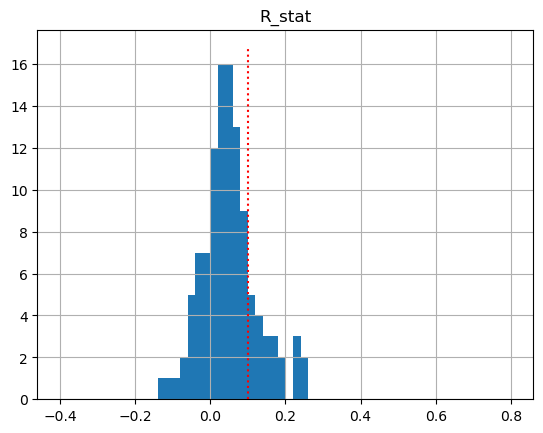

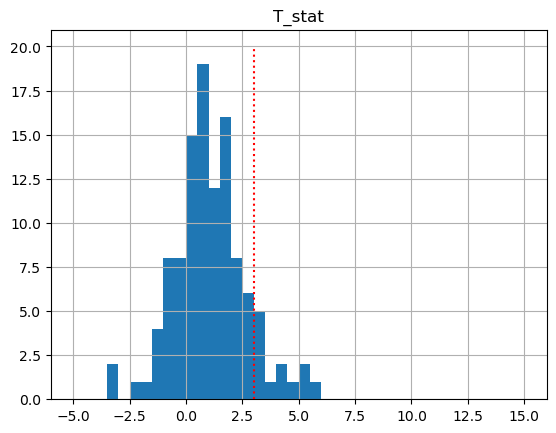

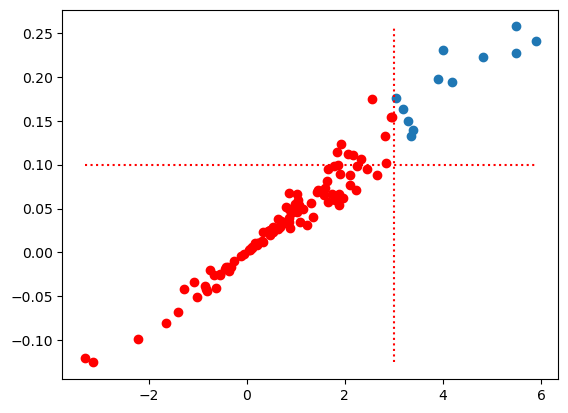

In [14]:
all_dfs = pd.concat(reg_dfs, ignore_index=True)
ax1 = all_dfs.hist(column="R_stat",bins=np.linspace(-0.4,0.8,61))
ax1[0][0].plot([0.1,0.1],ax1[0][0].get_ylim(),"r:")
ax2 = all_dfs.hist(column="T_stat",bins=np.linspace(-5,15,41))
ax2[0][0].plot([3,3],ax2[0][0].get_ylim(),"r:")
plt.show()

plt.plot([3,3], [all_dfs.R_stat.min(),all_dfs.R_stat.max()],"r:")
plt.plot([all_dfs.T_stat.min(),all_dfs.T_stat.max()],[0.1,0.1],"r:")
ignoring = (all_dfs.T_stat<3) | (all_dfs.R_stat<0.1)
plt.scatter(all_dfs.T_stat[ignoring], all_dfs.R_stat[ignoring], color="r")
plt.scatter(all_dfs.T_stat[~ignoring], all_dfs.R_stat[~ignoring])
plt.show()


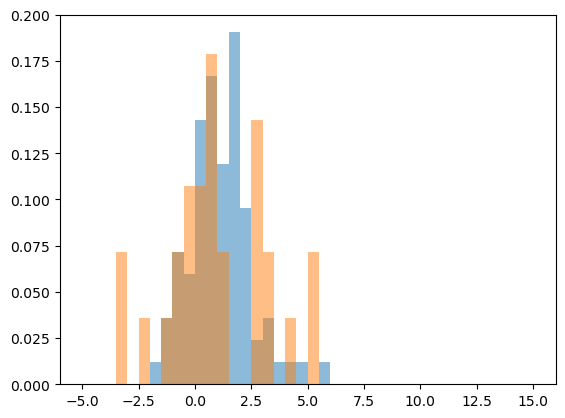

In [15]:
Tbins = np.linspace(-5,15,41)
plt.hist(all_dfs.T_stat[all_dfs.kind=="between"],bins=Tbins,
              weights=(1/sum(all_dfs.kind=="between")) * np.ones(sum(all_dfs.kind=="between")),
              histtype="stepfilled", color="C0", alpha=0.5)
plt.hist(all_dfs.T_stat[all_dfs.kind=="within"],bins=Tbins,
              weights=(1/sum(all_dfs.kind=="within")) * np.ones(sum(all_dfs.kind=="within")),
              histtype="stepfilled", color="C1", alpha=0.5)
plt.show()

In [16]:
gby = all_dfs.drop(columns="comparison").groupby(by=["ID","age","region","kind"]).mean().reset_index()
display(gby)
gby.loc[:,["region","R_stat","T_stat"]].groupby(by="region").diff().dropna()

,ID,age,region,kind,R_stat,T_stat
0,a5a41c,12,l_amy,between,0.161344,3.314247
1,a5a41c,12,l_amy,within,0.212022,4.580915
2,a5a41c,12,l_caudalmiddlefrontal,between,0.021491,0.701401
3,a5a41c,12,l_caudalmiddlefrontal,within,0.041013,1.155725
4,a5a41c,12,l_inferiortemporal,between,0.002700,0.052707
5,a5a41c,12,l_inferiortemporal,within,-0.050428,-1.371839
6,a5a41c,12,l_insula,between,0.059823,1.359621
7,a5a41c,12,l_insula,within,0.081468,1.652139
8,a5a41c,12,l_lateralorbitofrontal,between,0.063569,1.455255
9,a5a41c,12,l_lateralorbitofrontal,within,0.030731,0.706036


,R_stat,T_stat
1,0.050678,1.266668
3,0.019521,0.454324
5,-0.053128,-1.424545
7,0.021645,0.292518
9,-0.032838,-0.749219
11,-0.004003,-0.352924
13,-0.032900,-0.663629


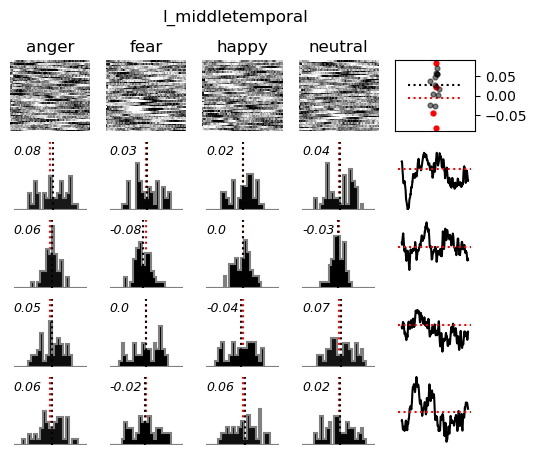

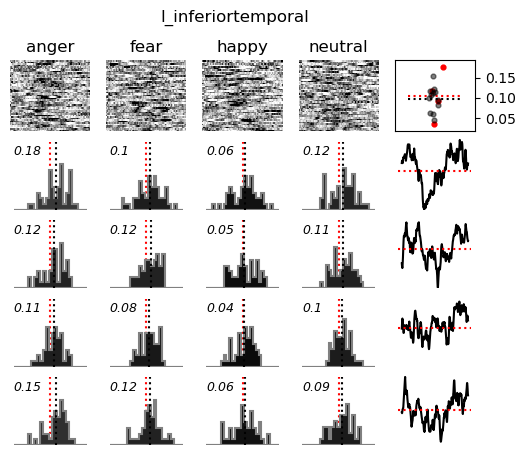

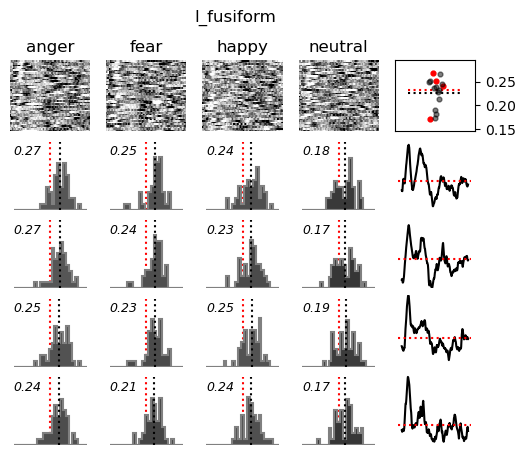

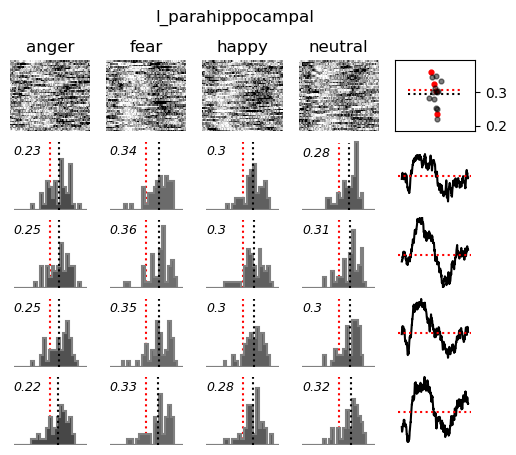

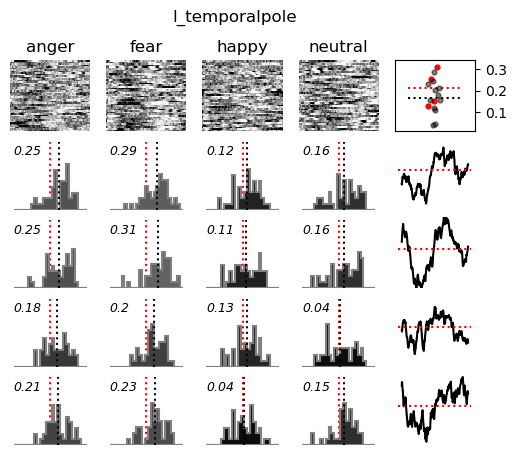

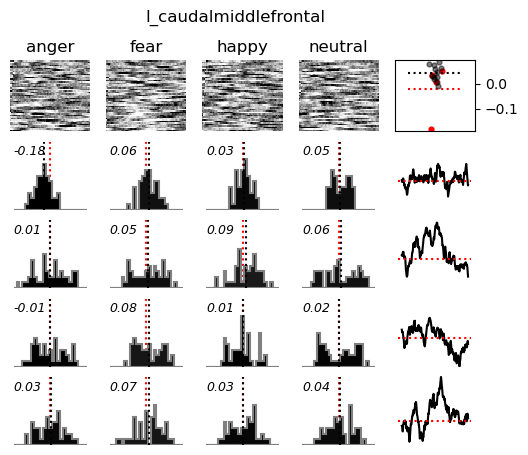

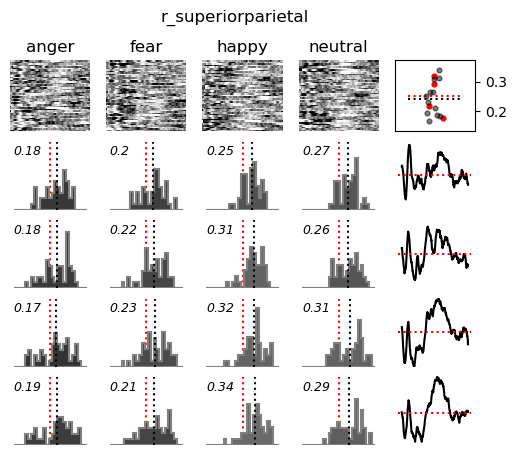

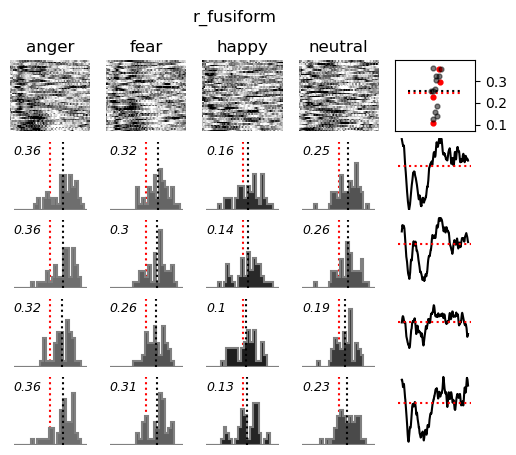

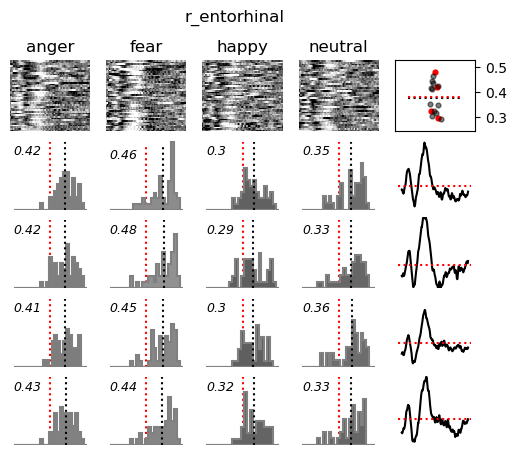

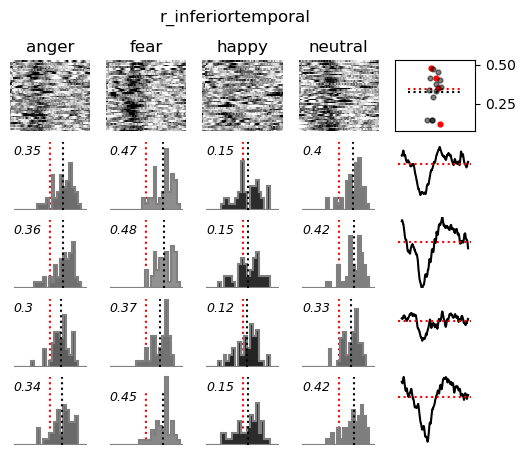

In [9]:
# make calculations

# ERPs or high-frequency broadband activity? (set True for HFB)
HFB_calc = False

# parameters for signal processing
resrate = 1024
lpfreq = 300
# time prior to (pre) and after (post) image onset
pre = -1
post = 2
# parameters for noise estimation
win_dur = 0.125 # seconds
MAD_thresh = 8.0 # median absolute deviations
min_dur = 0.125 # seconds

# for plotting
norm = mcolors.Normalize(vmin=0,vmax=1)
cmap = plt.get_cmap("Greys_r")

# collect df for each pair for later concatenation
reg_list = []
for pair in pairs_list:
    reg = montage.region[montage.name==pair[0]].item()
    # correlate each trial with the ERP for that category type
    # this will assess the within-vs-between-category similarity for each trial/category (per region)
    ts,signal,filtwins1 = filtering.bipolar_reref(data.loc[:,pair[::-1]],origfs,
                                                  resrate,lpfreq=lpfreq,norm="zscore")
    if HFB_calc:
        HFB = gaussian_filter(np.abs(hilbert(filtering.bfilt(signal, resrate, 4, [70,150], "bandpass"))),4)
        # HFB[norm_env>MAD_thresh] = np.nan
        signal = filtering.zscore(HFB)
        
    # get image onsets for filtered/resampled data
    t_ixs = np.array([np.where((ts>=(im_t+pre))&(ts<=(im_t+post))) for im_t in img_ts]).squeeze()
    # peri-stimulus time vector
    plot_ts = np.linspace(pre,post,t_ixs.shape[1])
    # define window of interest (image onset through following second)
    ixA = np.argmin(np.abs(plot_ts-0.0))
    ixB = np.argmin(np.abs(plot_ts-1))
    # see how many trials have amplitude excursions within the ERP window
    norm_env = spike_utils.envelope_noise_screen(signal, resrate, window_s=win_dur)
    # 500 ms of baseline
    base_ixs = np.array(t_ixs[:,:int(resrate/2)]-resrate/2,dtype=int)
    # filter the trials with too many amplitude excursions in the pre/post window
    t_mask = np.sum(np.int64((norm_env>MAD_thresh)[t_ixs]),axis=1)<(min_dur*resrate)
    # update t_mask to get rid of house trials
    t_mask = t_mask & (events.img_category!="house")
    # get category labels and index them
    cats, label_ix = np.unique(events.img_category[t_mask], return_inverse=True)
    # n instances per category
    counts = np.bincount(label_ix)
    
    # array of all trials (bad ones masked out)
    trials = signal[t_ixs[t_mask,ixA:ixB]]
    # calculate the ERPs for each category
    ERPs = np.array([trials[label_ix==ix,:].mean(axis=0) for ix in range(len(cats))]).T
    
    # center each matrix
    X = trials - trials.mean(axis=1, keepdims=True)
    Y = ERPs - ERPs.mean(axis=0, keepdims=True)
    
    # normalize by each trial/ERP's vector norm
    X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
    Y_norm = Y / np.linalg.norm(Y, axis=0, keepdims=True)
    all_corrs = X_norm @ Y_norm
    
    # leave one out correlation correctiong
    # i.e., calculate category ERPs without individual trials that belong to that category  
    loo_corrs = all_corrs.copy()
    for i, k in enumerate(label_ix):
        # apply leave-one-out correction for trial and matching ERP category
        y_loo = counts[k] * Y[:, k] - X[i]
        y_loo /= np.linalg.norm(y_loo)
    
        loo_corrs[i, k] = X_norm[i] @ y_loo
    
    # Ask how similar individual categories are to an average ERP
    fig,ax = plt.subplots(len(cats)+1, len(cats)+1, figsize=(6,5))
    
    matmin = np.percentile(trials[~np.isnan(trials)].flatten(),2.5)
    matmax = np.percentile(trials[~np.isnan(trials)].flatten(),97.5)
    
    cbins = np.linspace(-1,1,26)
    ymin=0; ymax=0
    
    # going to store T-scores for category comparisons
    ttmat = np.zeros((len(cats),len(cats)))
    for r,rcat in enumerate(cats):
        # get label index for current category
        lab_ix = np.flatnonzero(cats==rcat).item()
        # trials for that label
        cat_ts = label_ix==lab_ix
        # ERP for that label
        ERP = ERPs[:,lab_ix] # remember, was transposed
        ymin = min([ymin,min(ERP)])
        ymax = max([ymax,max(ERP)])
        # plot the ERP at the end of the current row
        ax[r+1,-1].plot(ERP,"k")
        ax[r+1,-1].plot(ax[r+1,-1].get_xlim(),[0,0],"r:")
        ax[r+1,-1].axis("off")
    
        # now, across cols in the row, fill in the correlation histograms
        for c,ccat in enumerate(cats):
            # get the label ix for column category
            axix = np.flatnonzero(cats==ccat).item()
            # all trials (instances) of that category
            axcat = label_ix == axix
            # correlations between instances of the column category (axcat) and ERP category [lab_ix]
            ECcorrs = loo_corrs[axcat,lab_ix] 
            fillc = ECcorrs.mean()
            # histogram of correlations between the ERP and current column category trials
            ax[r+1,c].hist(ECcorrs,bins=cbins, weights=(1/sum(axcat)) * np.ones(sum(axcat)),
                             histtype="stepfilled",facecolor=cmap(norm(fillc)), edgecolor=[0.5,0.5,0.5], lw=1.5)
            ax[r+1,c].axis("off")
            ax[r+1,c].plot([0,0],[0,0.25],"r:", zorder=0)
            ax[r+1,c].plot(np.ones(2)*fillc,[0,0.25],"k:")
            
            t_res = tt1(ECcorrs,0,alternative="two-sided").statistic
            ttmat[r,c] = fillc
            ax[r+1,c].text(-1,0.2,f"{round(fillc,2)}", size=9,style='italic')
            if r == 0:
                # cat_ts = groups[ccat]
                ax[r,c].pcolormesh(trials[axcat,:], shading="nearest",
                                   cmap=cmap, vmin=matmin, vmax=matmax,)
                ax[r,c].axis("off")
    
    diag = np.eye(ttmat.shape[0], dtype=bool)
    n_offs = np.sum(~diag)
    
    [ax[ix,-1].set_ylim(ymin,ymax) for ix in range(1,len(cats))]
    [ax[0,ix].set_title(cats[ix]) for ix in range(len(cats))]
    ax[0,-1].scatter(rng.normal(size=n_offs)*0.125,ttmat[~diag],s=12, color=[0,0,0,0.5])
    ax[0,-1].scatter(rng.normal(size=ttmat.size-n_offs)*0.125,ttmat[diag],s=12,color="r", zorder=0)
    ax[0,-1].plot([-1,1],np.ones(2)*ttmat[~diag].mean(),"k:",zorder=0)
    ax[0,-1].plot([-1,1],np.ones(2)*ttmat[diag].mean(),"r:",zorder=0)
    ax[0,-1].set_xticks([])
    ax[0,-1].set_xlim([-1.5,1.5])
    ax[0,-1].yaxis.set_label_position("right")
    ax[0,-1].yaxis.tick_right()
    ax[0,-1].set_ylim([ttmat.min()-(ttmat.max()*0.1),ttmat.max()*1.1])
    fig.subplots_adjust(hspace=0.1)
    fig.suptitle(reg)
    plt.show()